# HEART DISEASE PREDICTION

**Problem Statement:** Predict whether someone has a heart disease or not.

**Dataset:** Loan Approval Dataset ( Keggle Link : https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset )

Attribute Information:
- age
- sex (0 - Female , 1 - Male)
- chest pain type (4 values)
- resting blood pressure
- serum cholestoral in mg/dl
- fasting blood sugar > 120 mg/dl
- resting electrocardiographic results (values 0,1,2)
- maximum heart rate achieved
- exercise induced angina
- oldpeak = ST depression induced by exercise relative to rest
- the slope of the peak exercise ST segment
- number of major vessels (0-3) colored by flourosopy
- thal: 0 = normal; 1 = fixed defect; 2 = reversable defect
- Target : 0 - NO ; 1- YES

This notebook demonstrates the full project structure:
1. EDA
2. Cleaning & Preprocessing
3. Train Multiple ML models
4. Compare models using metrics
5. Select & justify the best model
6. Hyper-Parameter Tuning the Best Model
7. Predict on unseen data

## 1. Import Libraries 


In [121]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score,f1_score, roc_auc_score, confusion_matrix, classification_report
import warnings 
warnings.filterwarnings('ignore')


## 2. Load Dataset

In [ ]:
df = pd.read_csv('../datasets/heart.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


## 3. Exploratory Data Analysis (EDA)

In [123]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [124]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [125]:
# Checking Missing Value
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

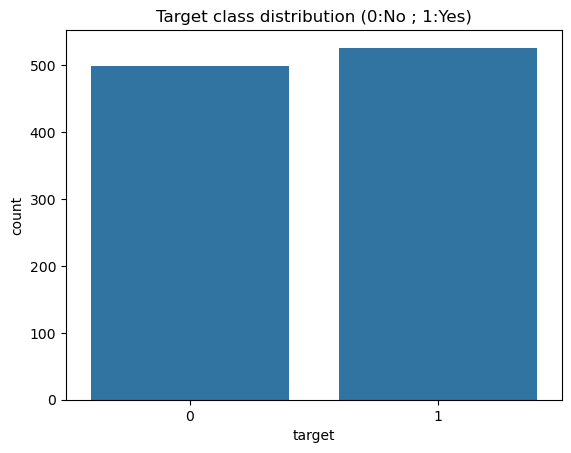

target
1    0.513171
0    0.486829
Name: proportion, dtype: float64

In [126]:
sns.countplot(x='target', data=df)
plt.title('Target class distribution (0:No ; 1:Yes)')
plt.show()
df.target.value_counts(normalize=True)

We can see that the target class is almost evenly distributed.

target      1.000000
cp          0.434854
thalach     0.422895
slope       0.345512
restecg     0.134468
fbs        -0.041164
chol       -0.099966
trestbps   -0.138772
age        -0.229324
sex        -0.279501
thal       -0.337838
ca         -0.382085
exang      -0.438029
oldpeak    -0.438441
Name: target, dtype: float64

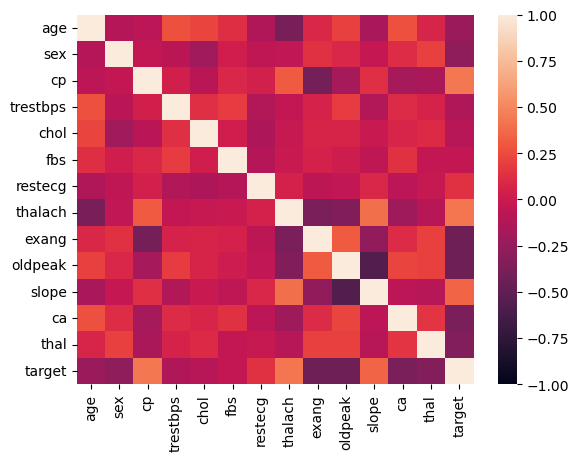

In [127]:
corr = df.corr()
sns.heatmap(corr, vmin=-1, vmax=1)
corr['target'].sort_values(ascending=False)


**EDA takeaways:**
- No missing values, so imputation is not needed.
- Target classes are balanced.

## 4. Data Cleaning and Preprocessing

In [128]:
X = df.drop('target',axis=1)
y = df.target

In [129]:
xtrain,xtest,ytrain,ytest = train_test_split(X,y,test_size=0.23,random_state=42)
xtrain.shape,ytest.shape

((789, 13), (236,))

In [130]:
scaler = StandardScaler()
xtrain = scaler.fit_transform(xtrain)
xtest = scaler.transform(xtest)

## 5. Train Classification Models

In [131]:
models = {
    'KNeighborsClassifier':KNeighborsClassifier(),
    'DecisionTreeClassifier':DecisionTreeClassifier(),
    'RandomForestClassifier':RandomForestClassifier(),
    'XGBClassifier':XGBClassifier(),
    'LogisticRegression':LogisticRegression(),
    'SVC':SVC()
}

In [132]:
def check_score(y_pred_test,y_test,y_pred_train,y_train):
    acctest = accuracy_score(y_test,y_pred_test)
    acctrain = accuracy_score(y_train,y_pred_train)
    rectest = recall_score(y_test,y_pred_test)
    rectrain = recall_score(y_train,y_pred_train)
    pretest = precision_score(y_test,y_pred_test)
    pretrain = precision_score(y_train,y_pred_train)
    roctest = roc_auc_score(y_test,y_pred_test)
    roctrain = roc_auc_score(y_train,y_pred_train)
    f1test = f1_score(y_test,y_pred_test)
    f1train = f1_score(y_train,y_pred_train)
    return acctest,acctrain,rectest,rectrain,pretest,pretrain,roctest,roctrain,f1test,f1train

In [133]:
res = []
for name,mod in models.items():
    model = mod
    model.fit(xtrain,ytrain)
    ytest_pred = model.predict(xtest)
    ytrain_pred = model.predict(xtrain)
    acctest,acctrain,rectest,rectrain,pretest,pretrain,roctest,roctrain,f1test,f1train = check_score(ytest_pred,ytest,ytrain_pred,ytrain)
    res.append({
                'Model Name':name,
                'Model':model,
                'Accuracy Test':acctest,
                'Accuracy Train':acctrain,
                'Recall Test':rectest,
                'Recall Train':rectrain,
                'Precision Test':pretest,
                'Precision Train':pretrain,
                'ROC AUC Test':roctest,
                'ROC AUC Train':roctrain,
                'F1 Score Test':f1test,
                'F1 Score Train':f1train
            })
    print(f"{name} Model Trained Sucessfully.")

KNeighborsClassifier Model Trained Sucessfully.
DecisionTreeClassifier Model Trained Sucessfully.
RandomForestClassifier Model Trained Sucessfully.
XGBClassifier Model Trained Sucessfully.
LogisticRegression Model Trained Sucessfully.
SVC Model Trained Sucessfully.


## 6. Comparing Performance of Models

In [134]:
result = pd.DataFrame(res).sort_values(by='Recall Test',ascending=False).reset_index(drop=True)
result_df = result.drop('Model',axis=1)
result_df

,Model Name,Accuracy Test,Accuracy Train,Recall Test,Recall Train,Precision Test,Precision Train,ROC AUC Test,ROC AUC Train,F1 Score Test,F1 Score Train
0,RandomForestClassifier,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
1,XGBClassifier,0.987288,1.000000,0.974359,1.000000,1.000000,1.000000,0.987179,1.000000,0.987013,1.000000
2,DecisionTreeClassifier,0.974576,1.000000,0.948718,1.000000,1.000000,1.000000,0.974359,1.000000,0.973684,1.000000
3,SVC,0.894068,0.955640,0.940171,0.963325,0.859375,0.951691,0.894455,0.955347,0.897959,0.957473
4,KNeighborsClassifier,0.826271,0.939163,0.871795,0.941320,0.796875,0.941320,0.826654,0.939081,0.832653,0.941320
5,LogisticRegression,0.783898,0.868188,0.871795,0.914425,0.739130,0.844244,0.784637,0.866423,0.800000,0.877934


Here, I compared the models based on `Recall_score` because it is related to medical and disease where `False Negative` is much more harmful than `False Positive` and Recall handles False Negative Better then Accuracy Or Precision.

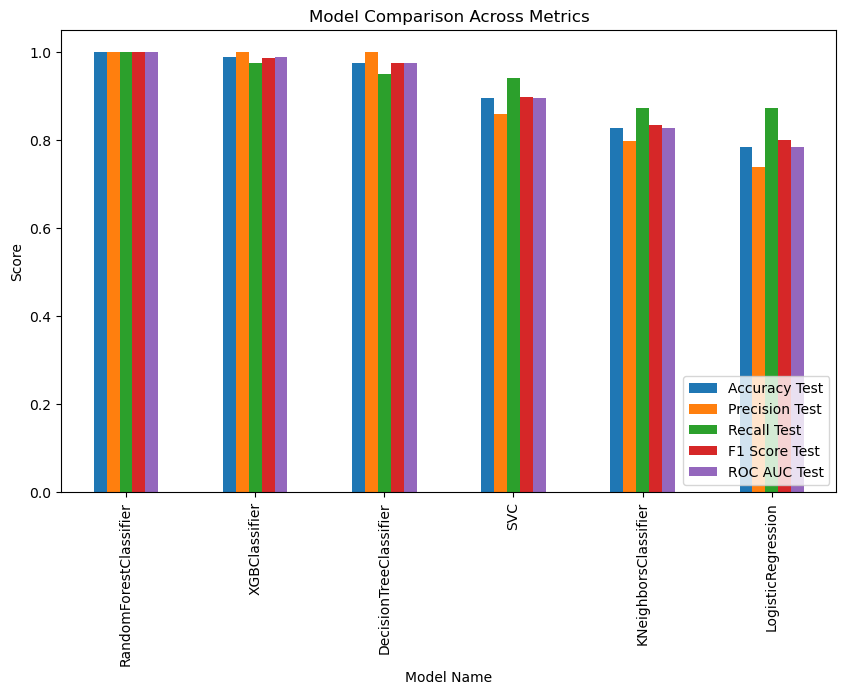

In [135]:
# Visual comparision of Metrices
result.set_index("Model Name")[["Accuracy Test", "Precision Test", "Recall Test", "F1 Score Test", "ROC AUC Test"]].plot(
    kind='bar', figsize=(10, 6)
)
plt.title("Model Comparison Across Metrics")
plt.ylabel("Score")
plt.xticks(rotation=90)
plt.legend(loc='lower right')
plt.show()

## 7. Select and Justify the Best Model

**Selection Logic :** Looking at the comparison table above, the **RFClassifier & XGBClassifier** model typically achieves the highest `Recall Score` and `ROC-AUC Score` among all the models.

In [136]:
best_model_name = result_df.iloc[0]["Model Name"]
best_model = result.iloc[0]['Model']
print(f"Best Model : {best_model_name}")

Best Model : RandomForestClassifier


## 8. Hyper-parameter Tuning

In [137]:
param = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", "log2"]
}
tuner = GridSearchCV(best_model,param_grid=param)

In [138]:
tuner.fit(xtrain,ytrain)

,estimator,RandomForestClassifier()
,param_grid,"{'max_depth': [None, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], ...}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [139]:
tuner.best_params_

{'max_depth': 10,
 'max_features': 'sqrt',
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 100}

In [140]:
rfc = RandomForestClassifier(max_depth=10, max_features='sqrt', min_samples_leaf=1, min_samples_split=2, n_estimators=100)
rfc.fit(xtrain,ytrain)

,n_estimators,100
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [141]:
rfc.fit(xtrain,ytrain)
ybest_test_pred = rfc.predict(xtest)
ybest_train_pred = rfc.predict(xtrain)
print(f"Test : {recall_score(ytest,ybest_test_pred)}")
print(f"Train : {recall_score(ytrain,ybest_train_pred)}")

Test : 0.9743589743589743
Train : 1.0


In [142]:
print(classification_report(ytest,ybest_test_pred, target_names=['No','Yes']))

              precision    recall  f1-score   support

          No       0.98      1.00      0.99       119
         Yes       1.00      0.97      0.99       117

    accuracy                           0.99       236
   macro avg       0.99      0.99      0.99       236
weighted avg       0.99      0.99      0.99       236



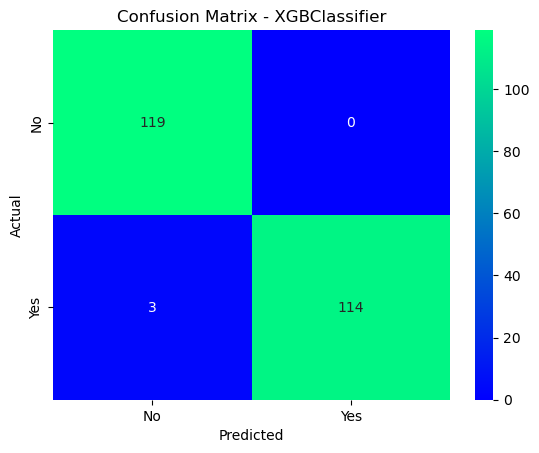

In [ ]:
cm = confusion_matrix(ytest,ybest_test_pred)
sns.heatmap(cm,annot=True,cmap='winter',fmt='d',yticklabels=['No','Yes'],xticklabels=['No','Yes'])
plt.title('Confusion Matrix - RandomForestClassifier')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [144]:
# Important Features
xtrain = pd.DataFrame(xtrain,columns=scaler.get_feature_names_out())
pd.DataFrame({'Features':xtrain.columns,
              'Importance':rfc.feature_importances_
              }).sort_values(by='Importance',ascending=False)

,Features,Importance
11,ca,0.139477
2,cp,0.137309
7,thalach,0.125072
9,oldpeak,0.118510
12,thal,0.117897
0,age,0.080688
4,chol,0.073925
3,trestbps,0.069590
10,slope,0.043506
8,exang,0.042355


## 9. Testing on Unseen Data


In [145]:
unseendata = xtrain.sample(5)
predections = rfc.predict(unseendata)
probs = rfc.predict_proba(unseendata)[:,0] 
results_unseen = unseendata.copy()
results_unseen['Predicted_Class'] = np.where(predections == 0, 'No', 'Yes')
results_unseen['Probablity (No)'] = probs.round(3)
results_unseen[['Predicted_Class','Probablity (No)']]

,Predicted_Class,Probablity (No)
99,No,1.000
48,Yes,0.001
614,Yes,0.015
245,No,0.802
258,No,1.000


## 10. Conclusion

- Trained and compared multiple classification models.
- The best-performing model was selected based on Recall Score, given the medical context.
- The selected model was used to predict on unseen samples successfully.